In [3]:
library(eRm) # digunakan untuk pemodelan rasch
library(dplyr) 
library(readxl) # digunakan untuk membaca file excel
library(psych)
library(ggplot2) # digunakan untuk membuat grafik
library(tidyr) # digunakan untuk merapikan data

In [4]:
source("fungsi/plotICC.R")
source("fungsi/wrightmap.R")
source("fungsi/treshold.R")

In [5]:
data <- read_excel("baruuu.xlsx") # membaca data menggunakan fungsi readxl dan menyimpannya di dataframe data
head(data, 5) # menampilkan 5 data teratas (mengecek apakah data sudah dibaca dengan benar oleh R)

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,3,1,3,3,3,0,3,3,4,4,3
3,3,1,4,2,3,2,2,2,3,2,2
2,3,1,2,0,3,4,2,2,1,2,3
2,3,1,3,0,1,0,4,3,1,2,3
3,4,1,4,1,2,0,0,2,4,3,2


In [23]:
# Menghitung Frekuensi Murni (Angka Riil)
f_mat <- t(apply(data[, paste0("S", 1:12)], 2, function(x) {
  table(factor(x, levels = 0:4))
}))

# Menghitung Proporsi Persentase
p_mat <- t(apply(data[, paste0("S", 1:12)], 2, function(x) {
  prop.table(table(factor(x, levels = 0:4))) * 100
}))

# Menyatukan keduanya menjadi format "F (P%)"
tabel_gabungan <- matrix(
  sprintf("%d (%.1f%%)", f_mat, p_mat), 
  nrow = nrow(f_mat), 
  dimnames = list(rownames(f_mat), paste("Skor", 0:4))
)

# 4. Tampilkan Hasil Akhir ke Konsol
print(tabel_gabungan, quote = FALSE)

    Skor 0     Skor 1     Skor 2     Skor 3     Skor 4    
S1  40 (39.2%) 5 (4.9%)   11 (10.8%) 45 (44.1%) 1 (1.0%)  
S2  3 (2.9%)   6 (5.9%)   32 (31.4%) 47 (46.1%) 14 (13.7%)
S3  56 (54.9%) 43 (42.2%) 3 (2.9%)   0 (0.0%)   0 (0.0%)  
S4  2 (2.0%)   38 (37.3%) 32 (31.4%) 24 (23.5%) 6 (5.9%)  
S5  26 (25.5%) 27 (26.5%) 27 (26.5%) 17 (16.7%) 5 (4.9%)  
S6  6 (5.9%)   10 (9.8%)  18 (17.6%) 57 (55.9%) 11 (10.8%)
S7  44 (43.1%) 1 (1.0%)   20 (19.6%) 7 (6.9%)   30 (29.4%)
S8  7 (6.9%)   2 (2.0%)   75 (73.5%) 12 (11.8%) 6 (5.9%)  
S9  6 (5.9%)   2 (2.0%)   52 (51.0%) 36 (35.3%) 6 (5.9%)  
S10 15 (14.7%) 14 (13.7%) 17 (16.7%) 26 (25.5%) 30 (29.4%)
S11 14 (13.7%) 22 (21.6%) 30 (29.4%) 23 (22.5%) 13 (12.7%)
S12 6 (5.9%)   19 (18.6%) 16 (15.7%) 56 (54.9%) 5 (4.9%)  


## 1. Estimasi Parameter Item Soal
### 1.1 Partial Credit Model (PCM)
PCM digunakan untuk mengukur probabilitas response pada soal dengan jawaban bersakala kategori. Misalnya soal esai dengan rentang jawaban 0-4. 0 adalah nilai terendah dan 4 adalah nilai tertiggi apabila dapat menjawab soal dengan benar. Sementara itu, nilai 1, 2 dan 3 digunakan sebagai kredit parsial. 

Secara matematis, PCM membangun probabilitas kategori respons (jawaban) dari rasio antara probabilitas kategori sebelumnya. Adapun rumus umum yang digunakan untuk menghitung probabilitasnya menurut Masters (1982) adalah sebagai berikut:
$$ 
\Pr(U_{pi}=x \mid \theta_p, \delta_{i1}, \dots, \delta_{im_i}) = 
\frac{ \exp \sum_{j=0}^{x} (\theta_p - \delta_{ij}) }{ 
\sum_{h=0}^{m_i} \exp \sum_{j=0}^{h} (\theta_p - \delta_{ij}) 
}
$$
Dengan ketetapan batasan (constraint) untuk j=0 nilai $\sum_{j=0}^{0} (\theta_p - \delta_{ij}) = 0$, sehingga nilai eksponensialnya bernilai 1.

Rumus di atas dapat diturunkan secara konkret untuk menghitung probabilitas respons pada instrumen skala tertentu. Sebagai contoh, jika kita mempunyai instrumen dengan 3 rentang kategori jawaban (skor 0, 1, dan 2), maka ekspansi rumus di atas untuk menentukan probabilitas masing-masing skor adalah sebagai berikut:
##### Probabilitas mendapatkan skor 0 ($U_{pi}$ = 0)
$$\Pr(U_{pi}=0 \mid \theta_p, \delta_{i1}, \delta_{i2}) = \frac{1}{1 + \exp(\theta_p - \delta_{i1}) + \exp(2\theta_p - \delta_{i1} - \delta_{i2})}$$
##### Probabilitas mendapatkan skor 1 ($U_{pi}$ = 1)
$$ 
\Pr(U_{pi}=1 \mid \theta_p, \delta_{i1}, \delta_{i2}) = 
\frac{\exp(\theta_p - \delta_{i1})}{1 + \exp(\theta_p - \delta_{i1}) + \exp(2\theta_p - \delta_{i1} - \delta_{i2})}
$$
##### Probabilitas mendapatkan skor 2 ($U_{pi}$ = 2)
$$ 
\Pr(U_{pi}=2 \mid \theta_p, \delta_{i1}, \delta_{i2}) = 
\frac{\exp(2\theta_p - \delta_{i1} - \delta_{i2})}{1 + \exp(\theta_p - \delta_{i1}) + \exp(2\theta_p - \delta_{i1} - \delta_{i2})}
$$

### 1.2 Rasio Probabilitas Kategori Berdekatan (Log-Odds)
Untuk memahami bagaimana PCM bekerja secara linier, model ini mengevaluasi rasio peluang antara dua kategori respons yang saling berurutan (k dan k−1).
##### Langkah 1 Rasio Probabilitas Berdampingan
Rasio probabilitas antara responden p memilih kategori k dibandingkan kategori sebelumnya (k−1) pada item i dirumuskan sebagai fungsi eksponensial dari selisih kemampuan dan kesulitan langkah:
$$ \frac{\Pr(U_{pi} = k \mid \theta_p, \delta_{i1}, \dots, \delta_{im})}{\Pr(U_{pi} = k-1 \mid \theta_p, \delta_{i1}, \dots, \delta_{im})} = \exp(\theta_p - \delta_{ik}) $$

##### Langkah 2 Transformasi Logaritma untuk Bentuk Linier
Dengan menerapkan operasi logaritma natural (log) pada kedua sisi persamaan, diperoleh bentuk linier log-odds (logit) yang menjadi ciri khas keluarga model Rasch:
$$ \log\left( \frac{\Pr(U_{pi} = k \mid \theta_p, \delta_{i1}, \dots, \delta_{im})}{\Pr(U_{pi} = k-1 \mid \theta_p, \delta_{i1}, \dots, \delta_{im})} \right) = \theta_p - \delta_{ik} $$
Dimana $k = 1,2, \dots ,m_i$​, dan $m_i$​ adalah skor maksimum untuk item $i$ (sehingga $U_{pi} \in \{0, 1, \dots, m_i\}$).

Sebagai ilustrasi, pada kasus instrumen dengan 3 kategori respons (skor 0, 1, 2) di atas, jika rumus probabilitas mutlak sebelumnya. 1 saling dibagi antar kategori yang berdampingan, maka penyebutnya yang rumit akan saling meniadakan dan menghasilkan model logit lokal sebagai berikut:
- Log-odds Kategori 0 vs 1:
$$ \log\left( \frac{\Pr(U_{pi} = 1 \mid \theta_p, \delta_{i1}, \delta_{i2})}{\Pr(U_{pi} = 0 \mid \theta_p, \delta_{i1}, \delta_{i2})} \right) = \theta_p - \delta_{i1} $$
- Log-odds Kategori 2 vs 1:
$$ \log\left( \frac{\Pr(U_{pi} = 2 \mid \theta_p, \delta_{i1}, \delta_{i2})}{\Pr(U_{pi} = 1 \mid \theta_p, \delta_{i1}, \delta_{i2})} \right) = \theta_p - \delta_{i2} $$

### 1.3 Proses Estimasi Conditional Maximum Likelihood (CML) dan Optimasi Numerik
Setelah fungsi probabilitas mutlak untuk setiap sel data respons diketahui, paket eRm tidak mengevaluasi skor individu satu per satu, melainkan menyusun seluruh probabilitas tersebut menjadi satu fungsi peluang bersama yang disebut Likelihood (L).

Untuk mengestimasi parameter item (δ) tanpa terdistorsi oleh parameter kemampuan responden ($\theta_p$​), digunakan metode Conditional Maximum Likelihood (CML). Pada metode ini, parameter $\theta_p$ dieliminasi dengan mengondisikan fungsi pada skor total mentah setiap responden ($r_v$​), menggunakan fungsi simetris dasar ($ \gamma_{rv} $). Persamaan Conditional Likelihood tersebut dirumuskan sebagai:
$$ 
L_c(\delta) = \prod_{v=1}^{N} \gamma_{rv}(\delta) \exp\left( -\sum_{i=1}^{I} \sum_{k=1}^{m_i} X_{vi} \delta_{ik} \right)
$$
Untuk mempermudah kalkulasi komputasi dan menghindari masalah underflow numerik pada perkalian pecahan yang massal, fungsi ini ditransformasikan menggunakan logaritma natural (ln), menghasilkan Conditional Log-Likelihood:
$$ 
\ln L_c = \sum_{v=1}^{N} \ln \left[ \Pr(\text{Data Aktual}_v \mid r_v, \delta) \right]
$$
Karena nilai probabilitas selalu berada di rentang 0 hingga 1, hasil akhir dari penjumlahan logaritma ini akan selalu bernilai negatif. 

Untuk menemukan nilai parameter kesulitan (δ) yang membuat nilai Log-Likelihood tersebut berada di titik paling maksimal (puncak kurva), komputer menerapkan algoritma iteratif Newton-Raphson. Algoritma ini berjalan dengan melakukan tebakan awal, menghitung turunan pertama (gradien) untuk melihat arah kemiringan, dan membaginya dengan turunan kedua (Matriks Hessian) untuk memperbarui nilai tebakan secara terus-menerus:
$$ 
\eta_{t+1} = \eta_t - H^{-1} \nabla \ln L_c(\eta_t)
$$
Proses koreksi tebakan ini dilakukan berulang kali hingga nilai Log-Likelihood sudah tidak mengalami perubahan yang berarti (konvergen).

In [6]:
rasch_model_pcm <- PCM(data)
summary(rasch_model_pcm)


Results of PCM estimation: 

Call:  PCM(X = data) 

Conditional log-likelihood: -1178.411 
Number of iterations: 51 
Number of parameters: 45 

Item (Category) Difficulty Parameters (eta): with 0.95 CI:
       Estimate Std. Error lower CI upper CI
S1.c2     1.526      0.352    0.836    2.217
S1.c3     0.387      0.273   -0.148    0.922
S1.c4     4.560      1.005    2.590    6.529
S2.c1    -0.728      0.692   -2.084    0.627
S2.c2    -2.342      0.577   -3.473   -1.211
S2.c3    -2.560      0.562   -3.662   -1.458
S2.c4    -1.073      0.602   -2.251    0.106
S3.c1     0.447      0.210    0.036    0.858
S3.c2     3.406      0.597    2.237    4.575
S4.c1    -2.914      0.703   -4.292   -1.536
S4.c2    -2.609      0.688   -3.959   -1.260
S4.c3    -2.081      0.682   -3.418   -0.744
S4.c4    -0.347      0.757   -1.830    1.137
S5.c1     0.040      0.275   -0.499    0.580
S5.c2     0.222      0.289   -0.344    0.788
S5.c3     0.970      0.346    0.293    1.648
S5.c4     2.582      0.528    1

### 1.4 Aplikasi dan Interpretasi Parameter Estimasi Empiris
Setelah proses estimasi CML mencapai konvergensi pada iterasi ke-51, model menghasilkan parameter kesulitan dasar (η) untuk setiap transisi kategori item. Sebagai bentuk aplikasi langsung dari teori yang telah dijabarkan, kita dapat membedah kluster parameter pada Soal 1 (S1) yang memiliki tiga parameter transisi terestimasi: `S1.c2` (η12​=1.526), `S1.c3` (η13​=0.387), dan `S1.c4` (η14​=4.560).
#### 1.4.1 Penerapan pada Rumus Linier Log-Odds
Berdasarkan rumus log-odds kategori berdekatan, nilai Estimate ini secara langsung menentukan fungsi peluang logit lokal responden untuk berpindah ke kategori yang lebih tinggi.
- Untuk Transisi Kategori 1 ke 2 (S1.c2):
$$ 
\log \left( \frac{\Pr(U_{p1} = 1)}{\Pr(U_{p1} = 2)} \right) = \theta_p - 1.526
$$
Interpretasi: Jika seorang responden memiliki kemampuan latent θp​=1.526, maka nilai log-odds menjadi 0, yang berarti peluangnya untuk mendapatkan skor 2 persis sama besar (50:50) dengan peluang mendapatkan skor 1.
- Untuk Transisi Kategori 3 ke 4 (S1.c4):
$$ 
\log \left( \frac{\Pr(U_{p1} = 3)}{\Pr(U_{p1} = 4)} \right) = \theta_p - 4.560
$$
Interpretasi: Nilai 4.560 yang sangat tinggi menunjukkan bahwa langkah untuk mendapatkan skor sempurna (skor 4) pada Soal 1 luar biasa sulit. Hanya responden dengan kemampuan θp​≥4.560 logit yang memiliki probabilitas ≥50% untuk berhasil melewati transisi dari skor 3 ke skor 4.

Jika kita perhatikan urutan nilai estimasi pada Soal 1:
$$ 
\eta_{12} \, (1.526) > \eta_{13} \, (0.387) < \eta_{14} \, (4.560)
$$
Terjadi pembalikan urutan di mana transisi menuju kategori 3 (0.387) secara matematis lebih rendah/mudah daripada transisi menuju kategori 2 (1.526). Dalam aplikasi PCM, fenomena ini disebut disordered thresholds.

Secara psikometris, ini menjadi indikasi awal bagi peneliti bahwa struktur penskoran parsial pada Kategori 2 di Soal 1 mungkin kurang dipahami oleh responden, atau batas kriteria antara skor 1, 2, dan 3 bertumpang tindih di lapangan.

Kolom lower CI dan upper CI merupakan aplikasi langsung dari pengujian signifikansi Wald menggunakan nilai standar error (Std. Error) yang diekstrak dari matriks Hessian. Kita dapat membuktikannya secara manual untuk parameter S1.c2:
- Nilai Estimasi ($\hat{\eta}$​): 1.526
- Kesalahan Baku (SE): 0.352
- Z-score (asumsi normal α=0.05): 1.96 (atau tepatnya 1.95996)
- `Batas Bawah (Lower CI)=1.526−(1.95996×0.352)=1.526−0.6899=0.8361≈0.836`
- `Batas Atas (Upper CI)=1.526+(1.95996×0.352)=1.526+0.6899=2.2159≈2.217`

Perhitungan manual di atas menghasilkan angka yang presisi dengan output komputer. Karena rentang interval kepercayaan pada S1.c3 mencakup angka nol (-0.148 sampai 0.922), ini berarti secara statistik, parameter kesulitan untuk transisi kategori 3 pada Soal 1 tidak berbeda signifikan dari nilai nol secara absolut pada skala logit.

## 2. Evaluasi

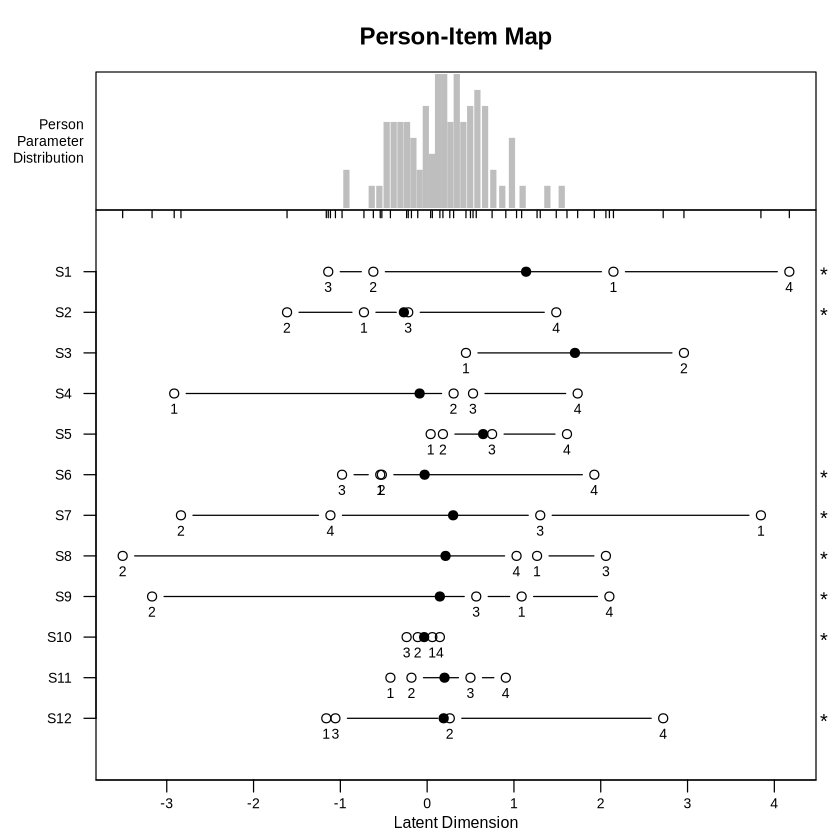

In [7]:
plotPImap(rasch_model_pcm)

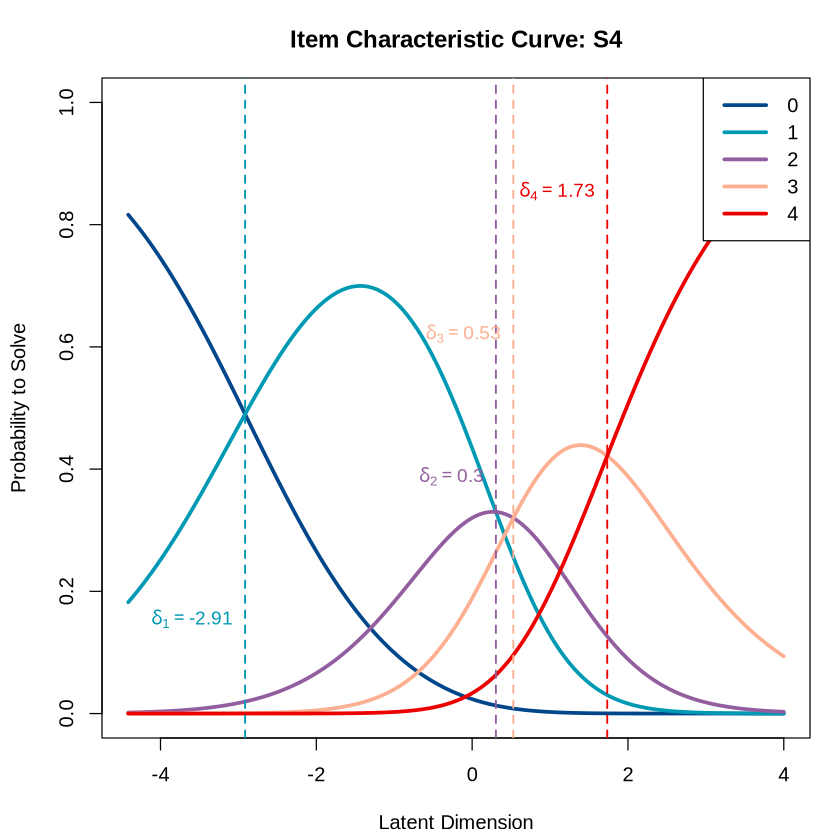

In [8]:
plot_icc(rasch_model_pcm, "S4")

### 2.1 Uji Unidimensionalitas
Secara ontologis, pengukuran dalam sains, baik sains fisik maupun psikometri mensyaratkan adanya kejelasan mengenai apa yang sedang diukur. Ketika kita menggunakan model keluarga Rasch seperti Partial Credit Model (PCM), kita terikat pada satu asumsi teoretis yang paling ketat dan mutlak, yaitu unidimensionalitas. Asumsi ini menyatakan bahwa seluruh butir soal di dalam instrumen harus bekerja secara serempak untuk mengukur satu dan hanya satu dimensi kemampuan laten tunggal (θ) pada diri responden.

Filosofi di balik pentingnya uji unidimensionalitas dapat dianalogikan dengan alat ukur fisik seperti timbangan. Jika kita ingin mengukur berat sebuah benda, alat ukur tersebut hanya boleh merespons gaya gravitasi objek (murni dimensi berat). Jika timbangan tersebut ternyata juga merespons suhu udara dan kelembapan ruangan secara bersamaan, maka angka kilogram yang keluar di layar menjadi tidak valid karena telah terkontaminasi oleh dimensi lain.

Dalam psikometri, jika sebuah instrumen dimaksudkan untuk mengukur "kemampuan penalaran statistik", maka varians jawaban responden murni harus digerakkan oleh kemampuan statistik mereka. Jika butir soal di dalamnya ditulis dengan kalimat yang terlalu rumit dan panjang, instrumen tersebut secara tidak sengaja akan mengukur dimensi lain, yaitu "kemampuan membaca pemahaman" (reading comprehension). Ketika sebuah instrumen bersifat multidimensional namun dipaksa dianalisis menggunakan model unidimensional seperti PCM, matematika di balik model tersebut akan dipaksa merata-ratakan dua atau lebih kemampuan yang berbeda ke dalam satu skor tunggal. Akibatnya, estimasi kemampuan orang (θ) dan tingkat kesulitan soal (η) yang dihasilkan oleh komputer menjadi cacat secara teoretis.

Tujuan utama dari uji unidimensionalitas ini adalah untuk bertindak sebagai "pintu gerbang penyaring" pertama dalam evaluasi model. Kita melakukan pengujian ini untuk membuktikan secara empiris bahwa sisaan (residuals) atau varians yang tidak tertangkap oleh dimensi utama murni merupakan white noise (acak dan tidak berpola). Melalui metode seperti Principal Component Analysis (PCA) of Residuals atau Martin-Löf Test, kita ingin memastikan bahwa tidak ada lagi faktor laten sekunder yang bersembunyi di balik pola jawaban responden.

Jika data terbukti murni unidimensional, kita mendapatkan jaminan ilmiah bahwa instrumen kita memiliki akurasi konseptual tinggi. Struktur linearitas pada konsep Log-Odds (Sub-bab 1.2) menjadi valid, dan kita memiliki landasan hukum yang sah untuk melanjutkan analisis ke tingkat stabilitas kelompok (Uji Andersen LR), ketajaman resolusi instrumen (Reliabilitas Separasi), hingga pemeriksaan anomali individu (Item & Person Fit). Semua angka terestimasi pada tahap lanjutan tersebut bermakna karena mereka bergerak di atas satu garis lurus dimensi yang sama.

Jika uji ini mendeteksi adanya dimensi sekunder yang dominan, hal ini menjadi alarm fatal bagi peneliti. Implikasinya, nilai Person Reliabilit berpotensi besar merupakan angka semu yang tidak bisa dipercaya. **Lebih jauh lagi hasil uji Andersen LR bisa jadi bukan disebabkan oleh sampel yang homogen, melainkan karena kelompok atas dan bawah mean tersebut sebenarnya sedang merespons dimensi laten yang berbeda. Jika kondisi ini terjadi, solusi praktisnya adalah kita harus memecah instrumen tersebut menjadi dua sub-tes yang berbeda, atau membuang item-item yang menjadi "penyusup" dimensi lain tersebut.**

In [9]:
mloef_median <- MLoef(rasch_model_pcm, splitcr = "mean")
mloef_median


Martin-Loef-Test (split criterion: mean)
LR-value: 184.706 
Chi-square df: 503 
p-value: 1 


Secara teoretis, p-value bergerak dari angka 0 hingga 1. Nilai p=1 berarti posisi nilai statistik LR (184.706) berada sangat jauh di dalam area penerimaan hipotesis nol pada kurva Chi-Square dengan df=503.

Secara matematis, nilai p=1 menunjukkan bahwa tidak ada perbedaan sama sekali antara skenario model unidimensional dan skenario model multidimensional. Skenario teoretis yang memaksa item menjadi satu dimensi ternyata pas, fit, dan melekat sempurna dengan realitas pola jawaban data mentah. 

##### Kesimpulan
- Instrumen erbukti secara empiris memenuhi asumsi keseragaman dimensi. Alat ukur ini murni, bersih, dan fokus hanya mengukur satu kemampuan laten tunggal dari responden tanpa tercampur oleh distorsi dari variabel laten luar (noise dimensi sekunder).
- Nilai p = 1 yang diperoleh memberikan jaminan matematis (berdasarkan prinsip kalkulus) yang sah. Terbuktinya unidimensionalitas data menjadikan peneliti memiliki landasan yang aman untuk melanjutkan estimasi dan uji diagnostik model. Reduksi butir, pemecahan subtes, maupun transformasi struktur data tidak diperlukan karena fondasi utama telah kokoh sejak awal.

### 2.2 Uji Invariansi Parameter (Andersen’s Likelihood Ratio Test)
Setelah parameter instrumen diestimasi menggunakan model PCM, langkah diagnostik fundamental berikutnya adalah membuktikan asumsi objektivitas spesifik (specific objectivity). Dalam paradigma Rasch, sebuah alat ukur yang valid mensyaratkan berlakunya invariansi parameter: tingkat kesulitan suatu soal (η) harus tetap stabil dan tidak berubah, terlepas dari apakah soal tersebut dikerjakan oleh kelompok responden yang memiliki kemampuan tinggi maupun rendah.

Untuk menguji stabilitas parameter ini, digunakan Andersen’s Likelihood-Ratio (LR) Test.

#### 2.2.1 Prinsip Matematis dan Hipotesis Uji
Uji Andersen LR mengevaluasi hipotesis nol (H0​) bahwa estimasi parameter kesulitan item bernilai konstan di seluruh sub-kelompok sampel. Pengujian ini beroperasi dengan membandingkan nilai probabilitas dari dua skenario estimasi komputasi:

- Skenario Terkekang (Constrained): Komputer memaksakan satu set parameter item global untuk seluruh sampel, menghasilkan satu nilai puncak probabilitas yang disebut $\ln L_c^{\text{(total)}}$.
- Skenario Bebas (Unconstrained): Sampel dibelah menjadi G kelompok. Komputer membiarkan parameter item diestimasi secara mandiri pada setiap sub-kelompok g, sehingga menghasilkan nilai puncak probabilitas yang dijumlahkan secara akumulatif: $\sum_{g=1}^{G} \ln L_c^{(g)}$.

Secara teoretis, skenario bebas selalu menghasilkan nilai log-likelihood gabungan yang lebih besar (atau kurang negatif) karena model lebih fleksibel mengikuti pola setiap kelompok. Uji LR menghitung selisih (rasio) antara kedua skenario tersebut melalui transformasi logaritma natural yang dirumuskan sebagai:
$$LR = -2 \ln \left( \frac{L_c^{(\text{total})}}{\prod_{g=1}^{G} L_c^{(g)}} \right) = 2 \left( \sum_{g=1}^{G} \ln L_c^{(g)} - \ln L_c^{(\text{total})} \right)$$
Transformasi pengali 2 (atau −2) pada rumus di atas berfungsi untuk mengonversi pecahan selisih logaritma tersebut menjadi angka positif yang mendistribusi mengikuti kurva Chi-Square (χ2). Derajat kebebasan (Degree of Freedom / df) pada distribusi ini dihitung berdasarkan jumlah kelompok pembelahan dan jumlah parameter yang diestimasi.

Dalam pengaplikasiannya menggunakan bahasa pemrograman R, algoritma dieksekusi melalui pemanggilan fungsi:
```R
LRtest(rasch_model_pcm, splitcr = "mean")
```
Dengan argumen splitcr = "mean", mesin eRm melakukan serangkaian proses komputasi di balik layar sebagai berikut:
1. Pembelahan Matriks Data: Komputer memindai skor mentah seluruh responden dan membelah matriks observasi menjadi dua kelompok (`G=2`): Kelompok di bawah rata-rata (kemampuan rendah) dan kelompok di atas rata-rata (kemampuan tinggi).
2. Estimasi Paralel: Algoritma Newton-Raphson dijalankan ulang dari nol secara terpisah untuk menghitung Matriks Hessian dan _Log-Likelihood_ pada masing-masing kelompok, seolah-olah mereka adalah dua penelitian yang berbeda.
3. Evaluasi Chi-Square: Nilai LR hasil perhitungan disandingkan dengan distribusi χ2. Karena target penelitian ini adalah membuktikan invariansi, maka hasil yang diharapkan adalah nilai p-value yang tidak signifikan (p>0.05). Nilai p yang besar bermakna bahwa selisih kelenturan antara model gabungan dan model terpisah sangat kecil (statistik LR mendekati nol), yang berarti parameter instrumen terbukti stabil.

In [10]:
lrt_mean_split <- LRtest(rasch_model_pcm, splitcr = "mean")
lrt_mean_split

Warning message in LRtest.Rm(rasch_model_pcm, splitcr = "mean"):
“
The following items were excluded due to inappropriate response patterns within
subgroups:
S1 S3 S5 S12 S4 S9 S2 S7 S8

Full and subgroup models are estimated without these items!”



Andersen LR-test: 
LR-value: 10.051 
Chi-square df: 11 
p-value:  0.526 


Pesan Warning menyatakan bahwa item S1, S3, S5, S12, S4, S9, S2, S7, dan S8 (total 9 item) didepak keluar dari analisis oleh paket eRm.

Ketika data dibelah berdasarkan mean, komputer membuat dua sub-matriks. Di dalam salah satu sub-matriks tersebut, ada kategori skor tertentu pada 9 item ini yang tidak diisi oleh satu pun responden (skor frekuensinya nol, atau terjadi structural zero).

Misalnya pada soal S1, tidak ada satu pun siswa di kelompok bawah-mean yang berhasil mendapatkan Skor 2, sehingga:
- Jika frekuensinya 0, maka probabilitasnya 0.
- Saat komputer mencoba menghitung Log-Likelihood kelompok tersebut, komputer harus menghitung nilai ln(0).
- Secara matematis, ln(0)=−∞ (minus tak terhingga).

Algoritma Newton-Raphson langsung macet karena komputer tidak bisa menghitung angka minus tak terhingga. Untuk menyelamatkan proses komputasi agar tidak crash, eRm membuang 9 item tersebut dari seluruh skenario pertandingan LR (baik model total maupun model kelompok).

Nilai $lnL_c​$ total dan kelompok yang menghasilkan angka LR=10.051 ini bukan dihitung dari seluruh instrumen soal. Angka ini murni hanya dihitung dari sisa item yang berhasil selamat dari warning di atas.

Secara statistik, nilai p-value: 0.526 > 0.05. Hipotesis nol (H0​) gagal ditolak, yang berarti secara formal kita bisa mengklaim: "Model invarian dan stabil lintas kelompok", namun model terbukti stabil hanya untuk beberapa item yang tersisa saja. Kita tidak bisa mengklaim 9 item yang dibuang itu bersifat invarian, karena mereka tidak ikut dihitung di dalam rumus LR.

In [39]:
# 1. Muat fungsi dari file eksternal (pastikan berada di folder/working directory yang sama)
source("fungsi/tabel_distribusi_lrt.R")

hasil_mean <- tabel_distribusi_lrt(data_matrix = data, 
                                   item_names = paste0("S", 1:12), 
                                   splitcr = "mean")

# Cetak ke konsol dengan perataan kanan absolut
print(hasil_mean, quote = FALSE, right = TRUE)

                 Skor 0     Skor 1     Skor 2     Skor 3     Skor 4 Status
S1 - Rendah  33 (70.2%)   2 (4.3%)   4 (8.5%)  8 (17.0%)   0 (0.0%)      *
S1 - Tinggi   7 (12.7%)   3 (5.5%)  7 (12.7%) 37 (67.3%)   1 (1.8%)       
                                                                          
S2 - Rendah    2 (4.3%)  6 (12.8%) 19 (40.4%) 13 (27.7%)  7 (14.9%)      *
S2 - Tinggi    1 (1.8%)   0 (0.0%) 13 (23.6%) 34 (61.8%)  7 (12.7%)       
                                                                          
S3 - Rendah  34 (72.3%) 13 (27.7%)   0 (0.0%)   0 (0.0%)   0 (0.0%)      *
S3 - Tinggi  22 (40.0%) 30 (54.5%)   3 (5.5%)   0 (0.0%)   0 (0.0%)       
                                                                          
S4 - Rendah    2 (4.3%) 21 (44.7%) 17 (36.2%)  5 (10.6%)   2 (4.3%)      *
S4 - Tinggi    0 (0.0%) 17 (30.9%) 15 (27.3%) 19 (34.5%)   4 (7.3%)       
                                                                          
S5 - Rendah  17 (36.2%) 1

### 2.3 Presisi Skala dan Reliabilitas Separasi
Setelah melakukan uji Andersen LR, kita tidak bisa langsung berpuas diri karena uji LR secara tunggal belum memberikan gambaran yang utuh mengenai kualitas pengukuran instrumen kita. Jika uji LR hanya memfokuskan pandangan kita pada stabilitas parameter (invariansi) saat dihadapkan pada kelompok yang berbeda, kita memerlukan uji presisi skala dan reliabilitas separasi untuk mengukur seberapa tajam resolusi instrumen dalam mendiferensiasi strata kesulitan soal maupun strata kemampuan responden secara nyata. Membedah informasi pemisahan tingkat kemampuan ini sangat penting untuk mendampingi interpretasi hasil LR sebelumnya; tanpa melihat kualitas sebaran varians dari metrik person reliability, kita akan dengan mudah terjebak pada kesimpulan yang keliru terkait fenomena tereliminasinya sembilan butir soal tadi, yang ternyata berakar dari terlalu homogennya sampel kita dan bukan karena instrumennya yang cacat.

Berbeda dengan Teori Tes Klasik (CTT) yang menggunakan Cronbach's Alpha untuk mengukur konsistensi internal secara global, paradigma model keluarga Rasch (termasuk PCM) mengevaluasi reliabilitas melalui metrik Indeks Separasi (Separation Index). Reliabilitas dalam konteks ini didefinisikan sebagai kemampuan instrumen untuk memisahkan atau mengelompokkan strata parameter secara konsisten, yang dihitung berdasarkan rasio antara varians sesungguhnya (True Variance) dan varians total (varians sesungguhnya ditambah varians kesalahan/ Error Variance). Pada analisis ini, evaluasi presisi skala dibagi menjadi dua metrik independen: Item Reliability dan Person Reliability.

In [11]:
# 1. PERSON RELIABILITY
person_pars <- person.parameter(rasch_model_pcm)
p_rel_obj   <- SepRel(person_pars)
person_reliability <- p_rel_obj$sep.rel

# 2. ITEM RELIABILITY
# eRm stores item parameters in $betapar as easiness values. 
# Multiplying by -1 turns them into difficulties.
item_difficulties <- -1 * rasch_model_pcm$betapar

# Extract the standard errors of those item parameters
item_se <- rasch_model_pcm$se.beta

# Compute item variance and mean error variance
observed_item_var   <- var(item_difficulties)
mean_item_error_var <- mean(item_se^2)

# Rasch Item Reliability Formula: (Observed Var - Error Var) / Observed Var
item_reliability <- (observed_item_var - mean_item_error_var) / observed_item_var

# 3. PRINT RESULTS
cat("=========================================\n")
cat("Rasch Reliability Metrics:\n")
cat("=========================================\n")
cat("Person Reliability (Separation): ", round(person_reliability, 3), "\n")
cat("Item Reliability (Separation)  : ", round(item_reliability, 3), "\n")
cat("=========================================\n")

Rasch Reliability Metrics:
Person Reliability (Separation):  0.62 
Item Reliability (Separation)  :  0.905 


##### Reliabilitas Item (Item Reliability)
Hasil komputasi menunjukkan nilai Item Reliability sebesar 0.905. Nilai yang mendekati 1.0 ini merepresentasikan metrik yang sangat baik. Secara psikometris, angka ini mengonfirmasi bahwa instrumen yang dikonstruksi memiliki hierarki tingkat kesulitan item yang sangat jelas dan terdefinisi dengan baik. Kesalahan standar (standard error) dari estimasi item sangat kecil dibandingkan dengan varians tingkat kesulitan di dalam instrumen. Dengan kata lain, model dengan sangat meyakinkan mampu memisahkan mana langkah (kategori) soal yang paling mudah hingga yang paling sulit.

##### Reliabilitas Responden (Person Reliability)
Berbeda dengan performa item, komputasi menghasilkan nilai Person Reliability sebesar 0.62. Dalam standar pemodelan Rasch, nilai ini tergolong lemah (secara umum nilai ≥0.80 diharapkan untuk pemisahan yang adekuat). Indeks 0.62 mengindikasikan bahwa instrumen kesulitan untuk secara presisi membedakan tingkatan kemampuan laten (θ) antar responden. Kelemahan ini umumnya tidak bersumber dari kualitas soal—mengingat Item Reliability sangat tinggi—melainkan menunjukkan bahwa sampel responden yang diuji memiliki tingkat kemampuan yang terlalu homogen (saling bertumpuk di rentang kemampuan yang sempit) atau rentang kesulitan soal secara keseluruhan kurang sejajar dengan rentang kemampuan sampel.

##### Kesimpulan
Temuan rendahnya Person Reliability ini memberikan landasan eksplanatori yang krusial terhadap anomali komputasional yang terjadi pada uji Andersen LR sebelumnya.

Ketika sampel dibelah menjadi dua kelompok menggunakan kriteria nilai rata-rata (splitcr = "mean"), homogenitas sampel (0.62) menyebabkan minimnya varians observasi di masing-masing sub-kelompok. Akibatnya, terjadi fenomena kategori kosong (structural zeros) pada kategori respons ekstrem di sembilan item (S1, S3, S5, S12, S4, S9, S2, S7, dan S8). Karena probabilitas empiris pada sel kosong bernilai 0, fungsi Log-Likelihood gagal mencapai konvergensi (menghasilkan nilai −∞), sehingga algoritma eRm secara otomatis mendiskualifikasi kesembilan item tersebut dari pengujian LR.

Oleh karena itu, meskipun hasil Andersen LR Test tidak menunjukkan signifikansi (p>0.05), konklusi stabilitas instrumen harus diinterpretasikan dengan mempertimbangkan limitasi varians sampel ini. Tingginya Item Reliability memastikan instrumen ini secara inheren kuat, namun homogenitas responden mensyaratkan perlunya uji diagnostik lanjutan pada tingkat kecocokan pola individual (fit statistics).

### 2.4 Item dan Person fit
Setelah mengidentifikasi adanya eliminasi massal pada uji Andersen LR dan mengevaluasi rendahnya reliabilitas pemisahan responden (Person Reliability), langkah konklusif kita berikutnya adalah melakukan uji kecocokan butir (item fit). Langkah ini bertujuan untuk memvalidasi apakah sembilan item yang tereliminasi tersebut secara inheren memang cacat (tidak sesuai dengan asumsi model PCM) atau sekadar menjadi korban dari homogenitas sampel saat data dibelah.

Metrik utama yang kita gunakan adalah Infit Mean Square (Infit MSQ) dan Outfit Mean Square (Outfit MSQ). Nilai harapan ideal untuk kedua metrik ini adalah 1.0. Berdasarkan standar pemodelan Rasch untuk tes performa/prestasi, rentang nilai MSQ yang dianggap sehat dan produktif untuk pengukuran adalah 0.5 hingga 1.5. Nilai >1.5 (underfit) mengindikasikan adanya noise atau pola jawaban yang terlalu acak (tidak terprediksi), sedangkan nilai <0.5 (overfit) mengindikasikan adanya redundansi atau pola jawaban yang terlalu kaku.

Sebelum membedah angka, kita harus memahami satu prinsip komputasi dasar: Fungsi itemfit mengevaluasi data berdasarkan Model Global (seluruh sampel digabung tanpa dibelah). Di tingkat global, seluruh kategori respons pada dua belas item ini terisi secara adekuat sehingga fungsi dapat menghitung nilai estimasinya tanpa terkendala angka minus tak terhingga (−∞). Hal ini memungkinkan kita melihat wajah asli dari sembilan item tersebut secara objektif.

#### 2.4.1 Analisis Kecocokan Butir (Item Fit Statistics)

In [12]:
itemfit(person.parameter(rasch_model_pcm))


Itemfit Statistics: 
      Chisq  df p-value Outfit MSQ Infit MSQ Outfit t Infit t Discrim
S1   76.388 101   0.968      0.749     0.785   -1.909  -2.282   0.606
S2   93.314 101   0.694      0.915     0.962   -0.521  -0.203   0.249
S3   90.663 101   0.760      0.889     0.914   -0.944  -0.724   0.432
S4  101.708 101   0.462      0.997     0.994    0.018  -0.014   0.276
S5  108.038 101   0.298      1.059     1.050    0.517   0.458   0.215
S6   96.788 101   0.600      0.949     0.916   -0.258  -0.538   0.347
S7  179.973 101   0.000      1.764     1.429    3.980   3.445  -0.041
S8  100.127 101   0.506      0.982     0.994   -0.032   0.030   0.106
S9   75.659 101   0.972      0.742     0.778   -1.618  -1.389   0.529
S10  82.940 101   0.905      0.813     0.800   -1.438  -1.809   0.530
S11  73.544 101   0.982      0.721     0.724   -2.576  -2.589   0.665
S12  88.530 101   0.808      0.868     0.877   -0.892  -0.955   0.422


Jika kita perhatikan output di atas, delapan dari sembilan item yang sebelumnya didepak dari uji Andersen LR (yaitu S1, S2, S3, S4, S5, S8, S9, dan S12) ternyata menunjukkan nilai Infit dan Outfit MSQ yang sangat baik.
- S4, sebagai contoh, memiliki Outfit MSQ 0.997 dan Infit MSQ 0.994 (sangat mendekati angka ideal 1.0).
- Nilai p-value untuk delapan item ini seluruhnya >0.05 (tidak signifikan), yang berarti secara statistik tidak ada penyimpangan bermakna dari model PCM teoretis
- Daya beda (Discrimination) juga bernilai positif berkisar antara 0.21 hingga 0.60.

Di antara seluruh item yang diuji, Soal 7 (S7) adalah satu-satunya item yang menunjukkan anomali ekstrem dan dapat dipastikan sebagai item yang cacat secara psikometris.
- Misfit Ekstrem: Nilai Outfit MSQ mencapai 1.764 dan Infit MSQ mencapai 1.429. Nilai Outfit yang bertengger jauh di atas batas aman 1.5 menunjukkan adanya noise atau deviasi jawaban yang sangat tinggi pada responden yang kemampuannya tidak sesuai dengan tingkat kesulitan soal tersebut.
- Signifikansi Statistik: Nilai p-value S7 adalah 0.000 (p<0.05) dengan nilai t yang sangat besar (Outfit t=3.980). Ini adalah bukti empiris mutlak bahwa S7 menolak asumsi model Rasch.
- Daya Beda Negatif: Nilai Discrimination S7 bernilai negatif, yaitu −0.041. Ini adalah kondisi paling fatal bagi sebuah butir soal. Nilai negatif mengindikasikan terjadinya polapikir terbalik: siswa yang berkemampuan tinggi secara laten justru gagal menjawab soal S7 dengan benar, sementara siswa dengan kemampuan rendah justru berhasil mendapatkan skor tinggi pada soal ini (kemungkinan besar akibat adanya cacat redaksi soal, kunci jawaban yang salah, atau maraknya unsur tebakan/konfusi).

##### Kesimpulan
- Konfirmasi Item Reliability (0.905): Tingginya nilai reliabilitas item yang kita temukan sebelumnya kini terbukti lewat tabel itemfit. Mayoritas item di dalam instrumen kita (11 dari 12 item) bekerja dengan sangat patuh mengikuti aturan matematika PCM. Instrumen kita secara umum tidak rusak.
- Justifikasi Warning LR Test: Kita sekarang tahu bahwa tereliminasinya sembilan item pada uji Andersen LR bukan karena item-item tersebut buruk, melainkan murni akibat keterbatasan sampel kita (Person Reliability 0.62). Karena responden kita terlalu homogen, varians jawaban mereka tersendat saat dibelah per kelompok rata-rata, padahal secara global (sebagaimana terbukti di tabel ini), item-item tersebut sangat fit dengan model.
- Isolasi Masalah pada S7: S7 adalah pengecualian. Item ini tidak fit secara global maupun lokal. Karakteristik S7 yang underfit dan memiliki daya beda negatif inilah yang menyuntikkan distorsi/noise ke dalam matriks data kita sejak awal, yang kemungkinan besar ikut memperparah terjadinya fenomena kategori kosong pada pengujian-pengujian sebelumnya.


#### 2.4.2 Analisis Kecocokan Responden (Person Fit Statistics)
Setelah membedah kualitas butir soal, kita sekarang harus menginvestigasi validitas pola jawaban responden secara individual melalui Person Fit Statistics. Jika uji reliabilitas separasi menunjukkan indeks 0.62 (lemah), analisis person fit ini berfungsi sebagai alat uji diagnostik untuk mendeteksi apakah rendahnya reliabilitas tersebut disebabkan oleh adanya responden yang memberikan pola jawaban tidak wajar atau menyimpang dari asumsi matematika model PCM.

Sama seperti uji butir, dua metrik utama yang kita gunakan adalah Infit Mean Square (Infit MSQ) dan Outfit Mean Square (Outfit MSQ) dengan nilai ekspektasi ideal 1.0 dan batas toleransi aman 0.5 hingga 1.5.

In [13]:
personfit(person.parameter(rasch_model_pcm))


Personfit Statistics: 
      Chisq df p-value Outfit MSQ Infit MSQ Outfit t Infit t
P1   13.442 11   0.265      1.120     1.651     0.40    1.19
P2    6.028 11   0.871      0.502     0.465    -1.24   -1.41
P3    6.596 11   0.831      0.550     0.735    -1.21   -0.76
P4   16.825 11   0.113      1.402     1.084     1.04    0.36
P5   21.336 11   0.030      1.778     1.475     1.68    1.30
P6    6.432 11   0.843      0.536     0.704    -1.28   -0.90
P7   34.835 11   0.000      2.903     2.491     3.30    2.73
P8   11.848 11   0.375      0.987     0.850     0.09   -0.35
P9   23.668 11   0.014      1.972     1.501     1.87    1.15
P10  20.738 11   0.036      1.728     1.443     1.64    1.30
P11   6.896 11   0.807      0.575     0.998    -0.96    0.15
P12   7.583 11   0.750      0.632     0.671    -0.90   -0.95
P13   8.910 11   0.630      0.743     0.828    -0.60   -0.44
P14   7.698 11   0.740      0.641     0.907    -0.84   -0.13
P15  12.082 11   0.357      1.007     0.934     0.15   -0.06


##### 2.4.2.1 Klasifikasi Pola Jawaban Responden
Berdasarkan data dari 102 responden teoretis (P1 sampai P102), kita dapat memetakan anomali perilaku pengerjaan soal ke dalam dua kategori kritis:

**Kelompok Misfit/Underfit Ekstrem (MSQ > 1.5 dan p<0.05)**

Kelompok ini diisi oleh para siswa yang memberikan pola jawaban yang sangat kacau, tidak terprediksi, dan penuh dengan noise. Ada 3 siswa dengan tingkat anomali yang luar biasa tinggi:
- P7 (p=0.000, Outfit MSQ = 2.903, Infit MSQ = 2.491)
- P74 (p=0.000, Outfit MSQ = 2.994, Infit MSQ = 2.340)
- P87 (p=0.000, Outfit MSQ = 2.992, Infit MSQ = 2.434)

Selain tiga subjek ekstrem di atas, terdapat beberapa siswa lain yang juga menembus batas aman 1.5, seperti P5, P9, P10, P51, P62, dan P81. Nilai Outfit MSQ yang mendekati angka 3.0 pada P7, P74, dan P87 mengindikasikan terjadinya fenomena lucky guessing (menebak beruntung) atau kecerobohan ekstrem. Siswa-siswa ini secara tak terduga berhasil mendapatkan skor tinggi pada soal-soal yang tingkat kesulitannya jauh di atas kemampuan laten mereka, namun di saat yang sama gagal total pada soal-soal mudah yang seharusnya bisa mereka kerjakan. 

**Kelompok Overfit Ekstrem (MSQ < 0.5)**

Kebalikan dari misfit, kelompok ini diisi oleh siswa yang pola jawabannya terlalu kaku, terlalu deterministik, dan terlalu patuh pada model (pola Guttman). Contoh paling mencolok adalah:

    P25 (p=0.997, Outfit MSQ = 0.192, Infit MSQ = 0.213)

Siswa lain seperti P22, P39, P41, P47, P52, dan P58 juga menunjukkan nilai MSQ di bawah 0.5. Pola jawaban yang terlalu sempurna dan dapat ditebak secara mutlak ini mengindikasikan adanya redundansi data, atau dalam skenario ekstrem lapangan, bisa menjadi sinyal indikasi adanya tindakan saling mencontek (cheating) sehingga varians jawaban mereka seragam.

##### Kesimpulan
- Kita mendapatkan bukti empiris bahwa rendahnya nilai reliabilitas pemisahan responden bukan karena kesalahan matematis model, melainkan karena data kita dikontaminasi oleh polusi varians dari siswa-siswa misfit ekstrem (terutama P7, P74, dan P87) yang memberikan error variance besar ke dalam penyebut rumus reliabilitas. Di sisi lain, siswa overfit seperti P25 mereduksi true variance sampel.
- Keberadaan siswa-siswa misfit yang menebak jawaban secara acak ini mengacak-acak distribusi frekuensi respons pada sub-kelompok sampel. Ketika kita membelah data berdasarkan nilai mean pada uji Andersen LR, kombinasi antara tumpukan sampel yang homogen, tarikan dari siswa overfit, dan kekacauan dari siswa misfit menyebabkan runtuhnya varians lokal, memicu sel kosong (structural zero), dan berujung pada didepaknya 9 item dari analisis stabilitas.
- Sangat besar kemungkinannya bahwa cacat psikometris pada Soal 7 (S7) (yang memiliki daya beda negatif dan underfit global) adalah pemicu utama lahirnya siswa-siswa misfit ini. Karakteristik S7 membuat siswa pintar salah menjawab dan siswa kurang pintar menjawab benar secara acak, yang secara otomatis merusak fit statistics personal para siswa tersebut.

#### Analisis Parameter Lokasi (Difficulty) dan Ambang Batas (Threshold)
Setelah merampungkan seluruh rangkaian uji evaluasi model dari tingkat makro hingga mikro, kita melakukan analisis parameter lokasi (location) dan ambang batas (threshold) sebagai tahap konklusi akhir dari investigasi instrumen ini. Jika uji diagnostik sebelumnya seperti Andersen LR Test dan Item/Person Fit berperan untuk mendeteksi "gejala" anomali pada data, maka analisis parameter pada bab ini berfungsi sebagai prosedur otopsi matematis untuk membongkar akar penyebab dari gejala-gejala tersebut. Melalui Partial Credit Model (PCM), kita tidak hanya mengukur tingkat kesulitan global sebuah butir soal (Location Parameter), melainkan membedah secara kalkulus tingkat kesulitan pada setiap transisi perpindahan skor skor secara bertahap (Threshold Parameter). Langkah terakhir ini sangat krusial untuk memetakan kualitas linearitas instrumen, memvalidasi fungsionalitas pembagian kategori skor, serta memberikan pembuktian teoritis final mengapa butir soal tertentu (seperti S7) terisolasi sebagai item yang cacat secara psikometris.

In [14]:
param_threshold <- thresholds(rasch_model_pcm)
print(param_threshold)


Design Matrix Block 1:
    Location Threshold 1 Threshold 2 Threshold 3 Threshold 4
S1   1.13996     2.14635    -0.61988    -1.13939     4.17276
S2  -0.26814    -0.72817    -1.61408    -0.21779     1.48748
S3   1.70287     0.44718     2.95857          NA          NA
S4  -0.08668    -2.91431     0.30488     0.52865     1.73406
S5   0.64538     0.04046     0.18169     0.74833     1.61105
S6  -0.02914    -0.54046    -0.52178    -0.98036     1.92603
S7   0.29946     3.84541    -2.83638     1.30301    -1.11422
S8   0.21198     1.26632    -3.50799     2.05951     1.03006
S9   0.14619     1.08858    -3.16922     0.56570     2.09971
S10 -0.03455     0.05970    -0.10812    -0.23645     0.14665
S11  0.20022    -0.42339    -0.18102     0.49899     0.90629
S12  0.19040    -1.16204     0.26086    -1.05675     2.71951



#### 1. Parameter Lokasi (Tingkat Kesukaran Global Butir)

*Location Parameter* ($\delta_i$) menunjukkan tingkat kesulitan umum dari suatu butir soal secara keseluruhan. Semakin tinggi nilai positifnya, semakin sulit soal tersebut bagi rata-rata responden. Sebaliknya, nilai negatif menunjukkan soal yang cenderung mudah.

* **Butir Soal Paling Sulit:** **S3** ($\delta = 1.70287$) dan **S1** ($\delta = 1.13996$). Kedua item ini membutuhkan tingkat kemampuan laten ($\theta$) yang sangat tinggi dari responden untuk bisa mendapatkan skor laten yang optimal.
* **Butir Soal Paling Mudah:** **S2** ($\delta = -0.26814$), **S4** ($\delta = -0.08668$), **S10** ($\delta = -0.03455$), dan **S6** ($\delta = -0.02914$). Nilai negatif pada keempat item ini menandakan bahwa mayoritas responden dalam sampel dapat melewati tingkat kesulitan global soal-soal ini dengan mudah.
* **Butir Soal Tingkat Moderat:** Item S5, S7, S8, S9, S11, dan S12 berada pada rentang positif rendah ($0.14$ hingga $0.64$), yang mengindikasikan tingkat kesulitan yang proporsional dan berada di sekitar rata-rata kemampuan sampel.

---

#### 2. Parameter Ambang Batas (Threshold Parameters)

*Threshold Parameter* ($\tau_{ik}$) merepresentasikan tingkat kesulitan yang dibutuhkan oleh responden untuk beralih atau naik dari satu kategori skor ke kategori skor tepat di atasnya (misalnya dari Skor 0 ke Skor 1, Skor 1 ke Skor 2, dan seterusnya).

##### A. Diferensiasi Jumlah Kategori Skor

* **Item Polikotomus 3 Kategori:** **S3** adalah satu-satunya item yang hanya memiliki 3 kategori respons (Skor 0, 1, dan 2). Hal ini ditunjukkan oleh nilai `NA` (Not Available) pada kolom *Threshold 3* dan *Threshold 4*.
* **Item Polikotomus 5 Kategori:** Sebelas item lainnya (S1, S2, S4 s.d S12) memiliki struktur 5 kategori respons (Skor 0, 1, 2, 3, dan 4) yang ditunjukkan oleh estimasi lengkap dari *Threshold 1* hingga *Threshold 4*.

##### B. Identifikasi *Ordered Thresholds* (Ambang Batas Berurutan)

Secara teoretis, struktur poin yang ideal harus menunjukkan nilai yang berurutan naik ($\text{Threshold 1} < \text{Threshold 2} < \text{Threshold 3} < \text{Threshold 4}$). Kondisi ini terpenuhi secara konsisten pada tiga item berikut:

* **S4:** $-2.914 \rightarrow 0.304 \rightarrow 0.528 \rightarrow 1.734$
* **S5:** $0.040 \rightarrow 0.181 \rightarrow 0.748 \rightarrow 1.611$
* **S11:** $-0.423 \rightarrow -0.181 \rightarrow 0.498 \rightarrow 0.906$

Pada ketiga item ini, fungsi penjenjangan skor berjalan secara linear: untuk mencapai skor yang lebih tinggi murni dibutuhkan kemampuan laten ($\theta$) yang semakin tinggi pula.

##### C. Identifikasi *Disordered Thresholds* (Ambang Batas Terbalik)

Sebagian besar item dalam instrumen ini mengalami *disordered thresholds*, di mana nilai batas transisi antar-skor saling melompat atau tumpang tindih:

* **Karakteristik Umum (S1, S2, S6, S8, S9, S10, S12):** Sebagai contoh pada **S1**, nilai bergerak dari $2.146 \rightarrow -0.619 \rightarrow -1.139 \rightarrow 4.172$. Pola penurunan pada *Threshold 2* dan *Threshold 3* ini mengindikasikan adanya penyempitan probabilitas kategori respons di lapangan, di mana responden yang sudah berhasil melewati Skor 1 cenderung akan langsung meluncur ke Skor 3 karena ambang batas di tengahnya bernilai minus (mudah).
* **Kasus Anomali Ekstrem (S7):** Item **S7** menunjukkan pola pergerakan *threshold* yang fluktuatif secara drastis atau berbentuk zig-zag ($3.845 \rightarrow -2.836 \rightarrow 1.303 \rightarrow -1.114$). Struktur ini menandakan disfungsi total pada pembagian bobot skor, di mana lompatan kesulitan dari Skor 0 ke Skor 1 sangat tinggi ($3.845$), namun untuk melompat dari Skor 1 ke Skor 2 justru menjadi sangat rendah ($-2.836$). Urutan ini berulang kembali secara tidak logis pada transisi skor berikutnya.

Warning message:
“package ‘ggrepel’ was built under R version 4.3.3”


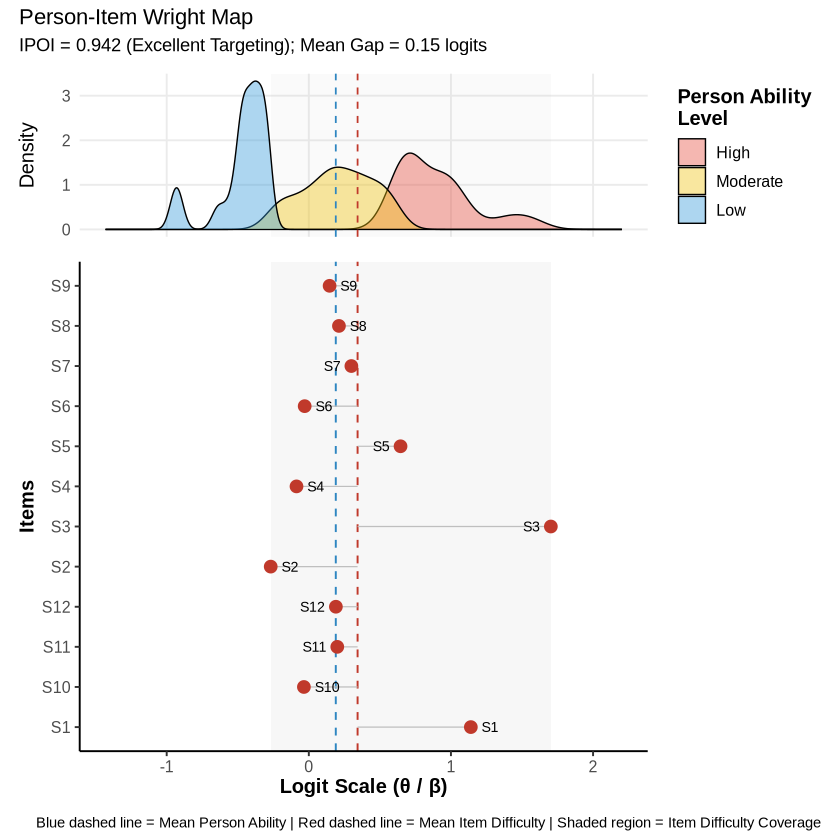

In [15]:
plot_wright_map(rasch_model_pcm)

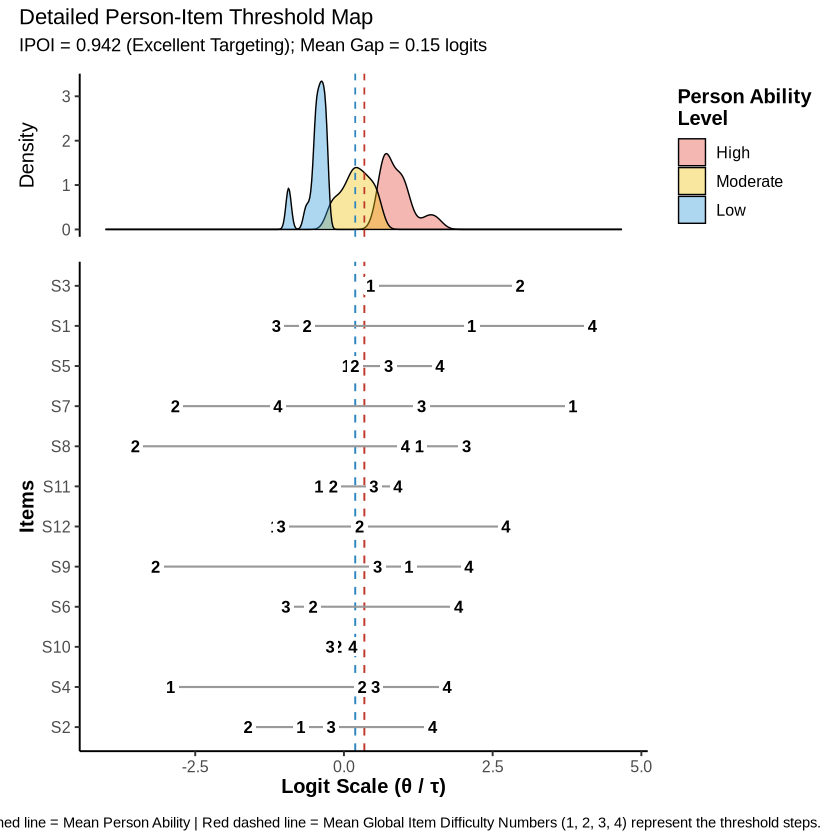

In [19]:
plot_threshold_map(rasch_model_pcm)

In [18]:
thresh_obj <- thresholds(rasch_model_pcm)

df_params <- data.frame(
  Item = rownames(thresh_obj$threshtable[[1]]),
  Calibration = round(
    thresh_obj$threshtable[[1]][, "Location"],
    6
  ),
  stringsAsFactors = FALSE
)

fit_obj <- itemfit(person.parameter(rasch_model_pcm))

df_fit <- data.frame(
  Item       = rownames(thresh_obj$threshtable[[1]]),
  Infit_MSQ  = as.numeric(fit_obj$i.infitMSQ),
  Outfit_MSQ = as.numeric(fit_obj$i.outfitMSQ),
  Infit_ZSTD = as.numeric(fit_obj$i.infitZ),
  Outfit_ZSTD = as.numeric(fit_obj$i.outfitZ),
  PTMEA      = as.numeric(fit_obj$i.disc),
  Discrim    = as.numeric(fit_obj$i.disc),
  stringsAsFactors = FALSE
)

final_table <- data.frame(
  Item        = df_params$Item,
  Calibration = round(df_params$Calibration, 4),
  Infit_MSQ   = round(df_fit$Infit_MSQ[match(df_params$Item, df_fit$Item)], 4),
  Outfit_MSQ  = round(df_fit$Outfit_MSQ[match(df_params$Item, df_fit$Item)], 4),
  Infit_ZSTD  = round(df_fit$Infit_ZSTD[match(df_params$Item, df_fit$Item)], 4),
  Outfit_ZSTD = round(df_fit$Outfit_ZSTD[match(df_params$Item, df_fit$Item)], 4),
  PTMEA       = round(df_fit$PTMEA[match(df_params$Item, df_fit$Item)], 4),
  Discrim     = round(df_fit$PTMEA[match(df_params$Item, df_fit$Item)], 4)
)

print(final_table)

   Item Calibration Infit_MSQ Outfit_MSQ Infit_ZSTD Outfit_ZSTD   PTMEA Discrim
1    S1      1.1400    0.7849     0.7489    -2.2819     -1.9091  0.6064  0.6064
2    S2     -0.2681    0.9616     0.9148    -0.2035     -0.5206  0.2493  0.2493
3    S3      1.7029    0.9138     0.8888    -0.7237     -0.9437  0.4325  0.4325
4    S4     -0.0867    0.9936     0.9971    -0.0143      0.0181  0.2758  0.2758
5    S5      0.6454    1.0500     1.0592     0.4577      0.5171  0.2155  0.2155
6    S6     -0.0291    0.9156     0.9489    -0.5383     -0.2576  0.3469  0.3469
7    S7      0.2995    1.4291     1.7644     3.4452      3.9805 -0.0410 -0.0410
8    S8      0.2120    0.9942     0.9816     0.0298     -0.0323  0.1056  0.1056
9    S9      0.1462    0.7775     0.7418    -1.3892     -1.6176  0.5295  0.5295
10  S10     -0.0346    0.8002     0.8131    -1.8085     -1.4383  0.5304  0.5304
11  S11      0.2002    0.7244     0.7210    -2.5890     -2.5761  0.6653  0.6653
12  S12      0.1904    0.8775     0.8679